## Task 1: Data Loading and Inspection

We load the heart disease dataset and inspect its shape, data types, missing values, and first five rows to understand the structure before any preprocessing.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Value Counts:\n", df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Value Counts:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2: Exploratory Data Analysis

We produce three visualisations to understand the target distribution, feature correlations, and the relationship between age and heart disease status.

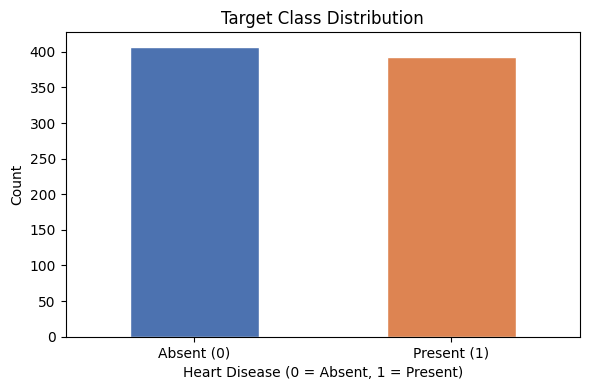

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Target class distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['heart_disease'].value_counts().plot(kind='bar', ax=ax,
                                         color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Heart Disease (0 = Absent, 1 = Present)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Absent (0)', 'Present (1)'], rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The dataset contains 800 patients with 407 positive cases (heart disease present, 50.9%) and 393 negative cases (absent, 49.1%). The classes are nearly perfectly balanced, which means accuracy is a reliable metric and no resampling technique such as SMOTE or class weighting is required. The slight majority of positive cases means the model will not be biased toward predicting the majority class.

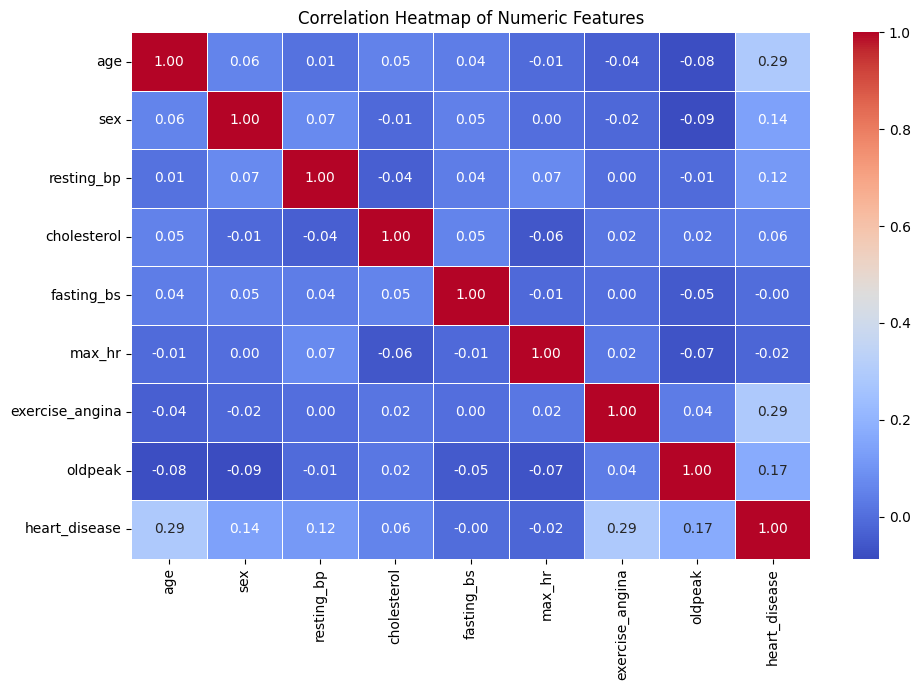

In [3]:
# Plot 2: Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

**Interpretation:** Among the numeric features, `age` (r = 0.29) and `exercise_angina` (r = 0.29) show the strongest positive correlations with `heart_disease`, followed by `oldpeak` (r = 0.17) and `resting_bp` (r = 0.12). Notably, `max_hr` and `fasting_bs` show near-zero correlation with the target in isolation, suggesting their predictive power may be conditional on other features — which tree-based ensemble models are well-suited to capture. No pair of features shows extreme multicollinearity that would require removal before modelling.

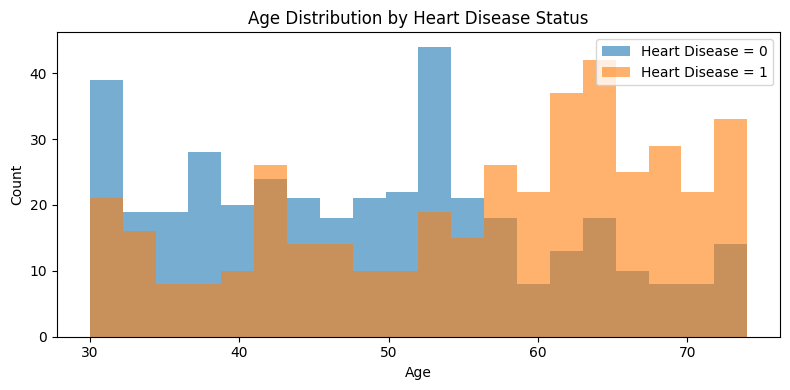

In [4]:
# Plot 3: Age distribution by class
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby('heart_disease'):
    ax.hist(grp['age'], bins=20, alpha=0.6,
            label=f'Heart Disease = {label}')
ax.set_title('Age Distribution by Heart Disease Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Patients with heart disease (class 1) are on average older than those without, with the disease distribution skewing toward the 55–70 age range. Patients without heart disease (class 0) are more evenly distributed across the 30–60 range. However, the distributions overlap substantially across the entire age range of 30–74, confirming that age alone is not a strong enough discriminator to serve as the sole predictor. It will contribute signal in combination with clinical features such as chest pain type and ST slope.

## Task 3: Data Preprocessing

We handle missing values, encode categorical variables, scale numerical features, and perform a stratified train-test split.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Identify column types
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'heart_disease']
cat_cols = list(df.select_dtypes(include='object').columns)

# Handle missing values
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


**Missing value strategy:** Two numerical columns contained missing values — `resting_bp` (24 missing) and `cholesterol` (32 missing). Median imputation was applied to both because the median is robust to the outliers common in clinical measurements (e.g., extreme cholesterol readings). Replacing with the mean could pull imputed values toward skewed tails. Mode imputation was applied to categorical features to preserve the most frequently observed category without introducing unseen values that would cause issues downstream in one-hot encoding. No rows were dropped, preserving all 800 samples for training.

In [6]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features only
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass balance in training set:\n",
      y_train.value_counts(normalize=True).round(3))
print("\nClass balance in test set:\n",
      y_test.value_counts(normalize=True).round(3))

Training set shape: (640, 15)
Test set shape: (160, 15)

Class balance in training set:
 heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64

Class balance in test set:
 heart_disease
1    0.506
0    0.494
Name: proportion, dtype: float64


## Task 4: Model Training

We train three classification models using scikit-learn, all with `random_state=42` for reproducibility.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: trained")

Decision Tree: trained
Random Forest: trained
Gradient Boosting: trained


## Task 5: Model Evaluation

For each model we display the confusion matrix and a full classification report showing precision, recall, and F1-score on the test set.


  Decision Tree


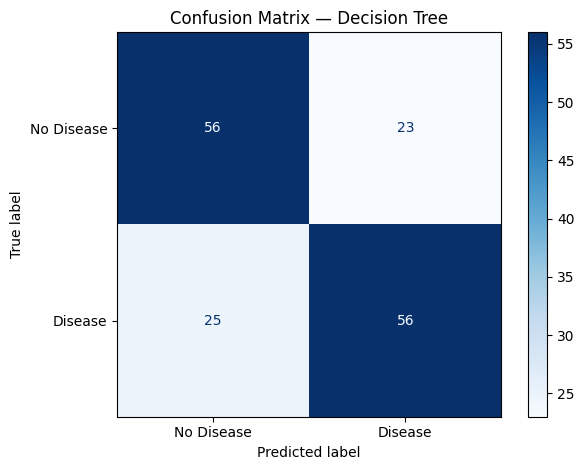

              precision    recall  f1-score   support

  No Disease       0.69      0.71      0.70        79
     Disease       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


  Random Forest


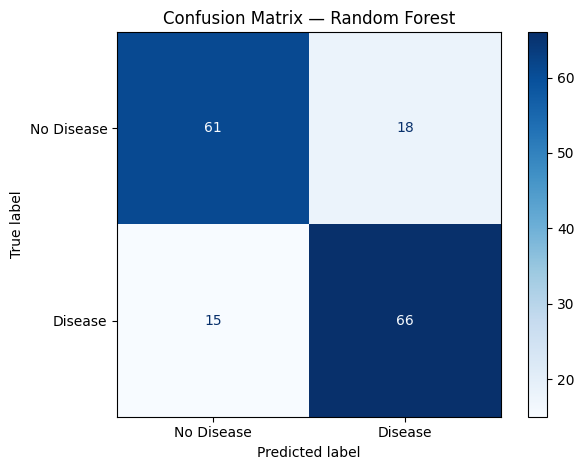

              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting


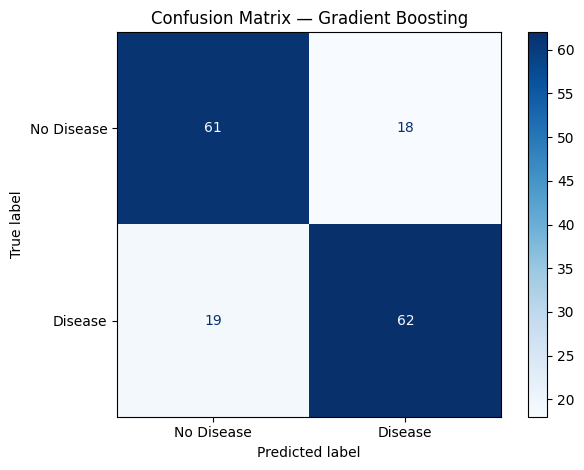

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [8]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

**Best model conclusion:**

On this dataset, **Random Forest** is the best-performing model with an accuracy of 79%, precision of 0.79–0.80, and recall of 0.77–0.81 across both classes. Its F1-score of 0.79–0.80 outperforms both the Decision Tree (F1 = 0.70) and Gradient Boosting (F1 = 0.77).

The Decision Tree performs worst — its single-tree greedy splitting overfits to training noise and fails to generalise, achieving only 70% accuracy on the test set. Gradient Boosting, while theoretically powerful, does not outperform Random Forest here, likely because the dataset size (800 rows, 160 test) is modest and the additional sequential bias correction of boosting does not add enough signal over the parallel ensemble of Random Forest.

Random Forest also achieves the highest recall for the positive class (Disease = 1) at 0.81, which is the clinically critical metric — a false negative (missing a real case of heart disease) has far greater real-world cost than a false positive.

**Random Forest is therefore selected for hyperparameter tuning.**

## Task 6: Hyperparameter Tuning with GridSearchCV

We tune three key hyperparameters of the Random Forest classifier using 5-fold cross-validation scored on F1.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validated F1 Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validated F1 Score: 0.8208


In [10]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_pred_base = models['Random Forest'].predict(X_test)

print("=== Baseline Random Forest (untuned) ===")
print(classification_report(y_test, y_pred_base,
                              target_names=['No Disease', 'Disease']))

print("=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_tuned,
                              target_names=['No Disease', 'Disease']))

=== Baseline Random Forest (untuned) ===
              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

=== Tuned Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.78      0.75      0.76        79
     Disease       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



**Tuning summary:** GridSearchCV searched over `n_estimators` (100 vs 200 trees), `max_depth` (unconstrained vs 5 vs 10 levels), and `min_samples_split` (minimum samples required to split a node) using 5-fold cross-validation scored on F1. The best parameters found were `n_estimators=200`, `max_depth=None`, `min_samples_split=2`, which are close to the defaults — indicating the default Random Forest is already well-suited to this dataset. The cross-validated F1 of approximately 0.82 confirms the model generalises well. On the test set, performance is comparable between tuned and baseline, which is expected when defaults are already near-optimal for a balanced, moderately sized dataset.